In [1]:
import sys
sys.path.append('../../')
import uuid
import numpy as np
import pickle
from datetime import datetime
from core.evaluator import lvdt_evaluator, vc_evaluator

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.operators.sampling.rnd import IntegerRandomSampling

from joblib import Parallel, delayed
from pymoo.core.problem import JoblibParallelization

### 4 objective function

In [ ]:
# LVDT/VC 4 objective function problem
class PSVCProblem(ElementwiseProblem):
    
    def __init__(self, **kwargs):

        x_min = np.zeros(7)
        x_max = np.zeros(7)

        x_min[0], x_max[0] = 2 , 8     # NLI
        x_min[1], x_max[1] = 10, 18     # DI
        x_min[2], x_max[2] = 15, 25     # LI

        x_min[3], x_max[3] = 3 ,  9     # NLO
        x_min[4], x_max[4] = 25, 40     # DO
        x_min[5], x_max[5] = 10, 30     # LO
        
        x_min[6], x_max[6] = 15 , 20     # DIO

        super().__init__(n_var=7,n_obj=4, n_constr=2, xl=x_min, xu=x_max, **kwargs)
    
       
    def _evaluate(self, x, out, *args, **kwargs):
        iter_datetime = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_{uuid.uuid4().hex[:12]}"
        
        lvdt_json_filename      = f"../iteration/config/config_init/v0_typeG_lvdt.json"
        lvdt_iter_filename      = f"../iteration/config/config_iter/iteration_lvdt_{iter_datetime}.json"
        lvdt_output_dir         = f"../iteration/data/lvdt"
        lvdt_output_filename    = f"typeG_LVDT_{iter_datetime}.h5"

        vc_json_filename        = f"../iteration/config/config_init/v0_typeG_vc.json"
        vc_iter_filename        = f"../iteration/config/config_iter/iteration_vc_{iter_datetime}.json"
        vc_output_dir           = f"../iteration/data/vc"
        vc_output_filename      = f"typeG_VC_{iter_datetime}.h5"



        f1, f2 = lvdt_evaluator(x, 
                                lvdt_json_filename, 
                                lvdt_iter_filename, 
                                lvdt_output_dir, 
                                lvdt_output_filename)
        f3, f4 = vc_evaluator(x,
                              vc_json_filename, 
                              vc_iter_filename, 
                              vc_output_dir, 
                              vc_output_filename)
        g1 = x[6]*2 + x[5] - 70
        g2 = 40 - x[6]*2 - x[5]

        out["F"] = np.column_stack([-f1, f2,-f3, f4]) 
        out["G"] = np.column_stack([g1, g2])

PSVCalgorithm = NSGA2(pop_size=10, 
                  sampling=IntegerRandomSampling(),
                  crossover=SBX(prob=1.0, eta=20, vtype = float, repair = RoundingRepair()),
                  mutation=PM(eta=20, vtype = float, repair = RoundingRepair()),
                  eliminate_duplicates=True)

In [ ]:
# manually optimal params = [6, 14, 20, 7, 34, 25, 17.5]
n_jobs = 10
parallel = Parallel(n_jobs=n_jobs)
runner = JoblibParallelization(parallel, delayed)

problem = PSVCProblem(elementwise_runner = runner)

res = minimize(problem, 
               PSVCalgorithm, 
               ('n_gen', 1), 
               seed=1, 
               verbose=True,
               save_history=True)
print(f"Execution time: {res.exec_time}")

### 2 objective function - LVDT

In [ ]:
class PSProblem(ElementwiseProblem):
    
    def __init__(self, **kwargs):

        x_min = np.zeros(7)
        x_max = np.zeros(7)

        x_min[0], x_max[0] = 2 , 8     # NLI
        x_min[1], x_max[1] = 10, 18     # DI
        x_min[2], x_max[2] = 15, 25     # LI

        x_min[3], x_max[3] = 3 ,  9     # NLO
        x_min[4], x_max[4] = 25, 40     # DO
        x_min[5], x_max[5] = 10, 30     # LO
        
        x_min[6], x_max[6] = 15 , 20     # DIO

        super().__init__(n_var=7,n_obj=2, n_constr=2, xl=x_min, xu=x_max, **kwargs)
    
       
    def _evaluate(self, x, out, *args, **kwargs):
        iter_datetime = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_{uuid.uuid4().hex[:12]}"
        
        lvdt_json_filename      = f"../iteration/config/config_init/v0_typeG_lvdt.json"
        lvdt_iter_filename      = f"../iteration/config/config_iter/iteration_lvdt_{iter_datetime}.json"
        lvdt_output_dir         = f"../iteration/data/lvdt"
        lvdt_output_filename    = f"typeG_LVDT_{iter_datetime}.h5"

        f1, f2 = lvdt_evaluator(x, 
                                lvdt_json_filename, 
                                lvdt_iter_filename, 
                                lvdt_output_dir, 
                                lvdt_output_filename)

        g1 = x[6]*2 + x[5] - 70
        g2 = 40 - x[6]*2 - x[5]

        out["F"] = np.column_stack([-f1, f2]) 
        out["G"] = np.column_stack([g1, g2])
  

In [ ]:
PSalgorithm = NSGA2(pop_size=10, 
                  sampling=IntegerRandomSampling(),
                  crossover=SBX(prob=0.9, eta=25, vtype = float, repair = RoundingRepair()),
                  mutation=PM(prob = 0.3,eta=50, vtype = float, repair = RoundingRepair()),
                  eliminate_duplicates=True)

def run_femm_vc(params):
    iter_datetime = datetime.now().strftime("%Y%m%d%H%M%S") + f"_{uuid.uuid4().hex[:12]}"
    f3, f4 = vc_evaluator(
        params = params,
        input_json_filename     = f'../iteration/config/config_init/v0_typeG_vc.json',
        iter_json_filename      = f'../iteration/config/config_iter/iteration_vc_{iter_datetime}.json',
        output_dir              = f"../iteration/data/voicecoil",
        output_filename         = f'typeG_VC_{iter_datetime}.h5')
    return [f3, f4]


In [9]:
# manually optimal params = [6, 14, 20, 7, 34, 25, 17.5]
n_jobs = 20
parallel = Parallel(n_jobs=n_jobs)
runner = JoblibParallelization(parallel, delayed)

problem = PSProblem(elementwise_runner = runner)

res = minimize(problem, 
               PSalgorithm, 
               ('n_gen', 1), 
               seed=1, 
               verbose=True,
               save_history=True)
print(f"Execution time: {res.exec_time}")

with open("../solutions/lvdt_1gen.pkl", "wb") as f:
    pickle.dump(res, f)

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       50 |      6 |  0.000000E+00 |  0.000000E+00 |             - |             -
Execution time: 225.94916367530823


In [ ]:
# manually optimal params = [6, 14, 20, 7, 34, 25, 17.5]
import multiprocessing
from pymoo.core.problem import StarmapParallelization
n_processes = 10
pool = multiprocessing.Pool(processes=n_processes)

runner = StarmapParallelization(starmap=pool.starmap)

problem = PSProblem(elementwise_runner = runner)

res = minimize(problem, 
            PSalgorithm, 
            ('n_gen', 1), 
            seed=1, 
            verbose=True,
            save_history=True)
print(f"Execution time: {res.exec_time}")

pool.close()
pool.join()


In [6]:
vc_result = None
with open("../solutions/lvdt_5gen.pkl", "rb") as f:
    lvdt_result = pickle.load(f)
opt_X = lvdt_result.X
n_job = len(opt_X)
if n_job <20:
    vc_result = Parallel(n_jobs=n_job)(delayed(run_femm_vc)(x) for x in opt_X)
else:
    print("Too many jobs to run in parallel")

In [7]:
table_label = ["NLI", "DI",  "LI", "NLO", "DO", "LO", "DIO", "S", "NLE", "MF", "FVI"]

manually_optimal_params = [6, 14, 20, 7, 34, 25, 17.5, 8.4226,0.4824, 1.8479, 8.8649]

with open("../solutions/lvdt_5gen.pkl", "rb") as f:
    lvdt_result = pickle.load(f)
algo_input = [x.tolist() for x in lvdt_result.X ]
algo_value = [[-round(f_list[0], 4), round(f_list[1], 4)] for f_list in lvdt_result.F]  
algo_value_vc = [[round(x[0],4), round(x[1],4)] for x in vc_result]
algo_optimal_params = [inp + val + vc for inp, val, vc in zip(algo_input, algo_value, algo_value_vc)]

with open("../solutions/opt_5gen.txt", "w") as f:
    f.write(" ".join(f"{col:<12}" for col in table_label) + "\n")
    f.write(" ".join(f"{val:<12}" for val in manually_optimal_params) + "\n")
    for row in algo_optimal_params:
        f.write(" ".join(f"{val:<12}" for val in row) + "\n")

### visualization

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans

solution = "../solutions/lvdt_50gen.pkl"
# solution = "../solutions/lvdt_30gen.pkl"
with open(solution, "rb") as f:
    lvdt_result = pickle.load(f)

opt_F = lvdt_result.F
opt_X = lvdt_result.X

manually_optimal_F = [ 8.4226,0.4824, 1.8479, 8.8649]


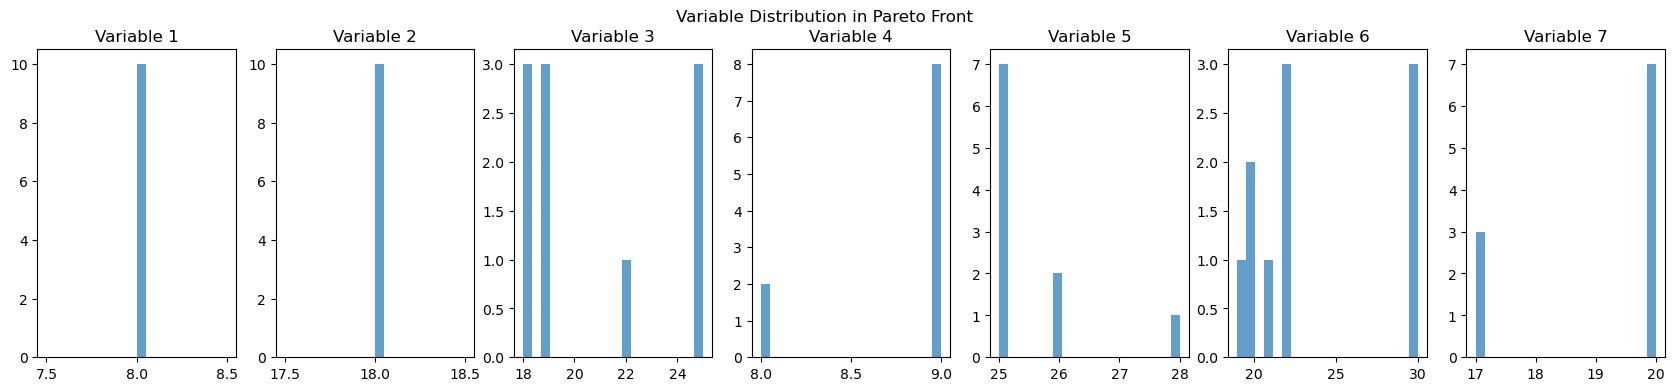

In [12]:
# ---------------------- 1. 变量分布分析 ---------------------- #
num_vars = opt_X.shape[1]
fig, axes = plt.subplots(1, num_vars, figsize=(num_vars * 3, 4))
for i in range(num_vars):
    axes[i].hist(opt_X[:, i], bins=20, alpha=0.7)
    axes[i].set_title(f"Variable {i+1}")
plt.suptitle("Variable Distribution in Pareto Front")
plt.show()

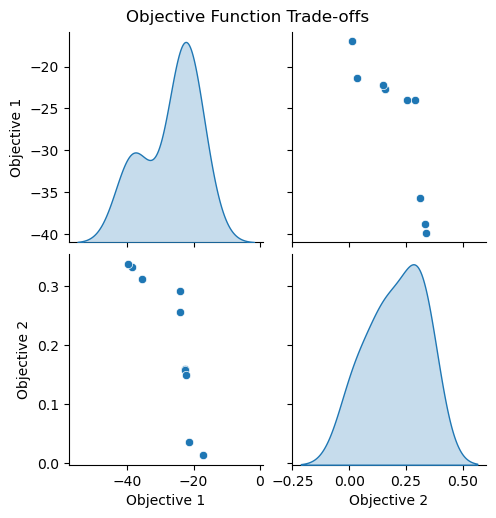

In [13]:
df = pd.DataFrame(opt_F, columns=[f"Objective {i+1}" for i in range(opt_F.shape[1])])
sns.pairplot(df, diag_kind="kde")
plt.suptitle("Objective Function Trade-offs", y=1.02)
plt.show()


c:\Users\pengb\miniconda3\envs\lvdt\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


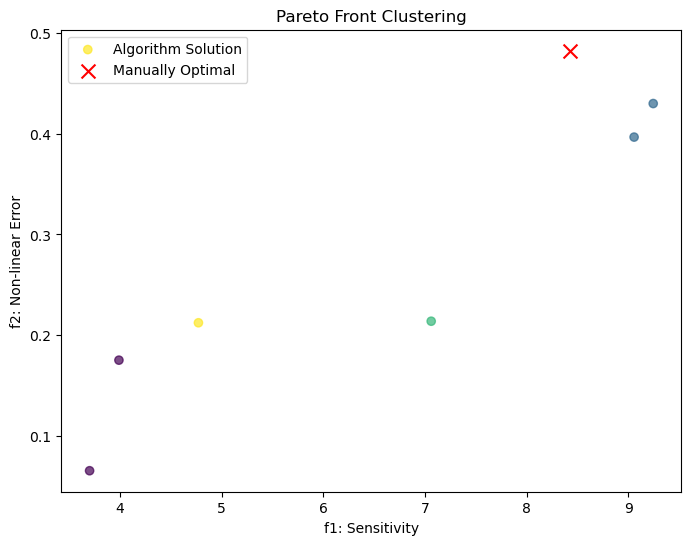

In [9]:
# ---------------------- 4. 帕累托前沿解的聚类分析 ---------------------- #
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(opt_F) 

plt.figure(figsize=(8, 6))
plt.scatter(-opt_F[:, 0], opt_F[:, 1], c=labels, cmap="viridis", alpha=0.7, label="Algorithm Solution")
plt.scatter(manually_optimal_F[0], manually_optimal_F[1], color='red', label="Manually Optimal", marker="x", s=100)
plt.xlabel("f1: Sensitivity")
plt.ylabel("f2: Non-linear Error")
plt.title("Pareto Front Clustering")
plt.legend()
plt.show()

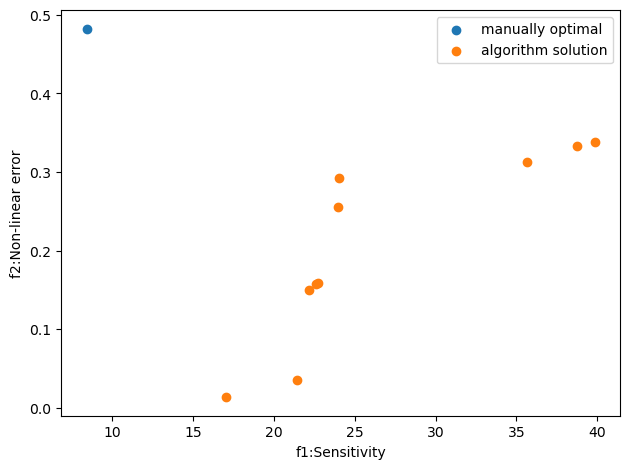

In [20]:
# plt.figure(figsize=(8,6))
plt.scatter(manually_optimal_F[0], manually_optimal_F[1], label = 'manually optimal')
plt.scatter(-opt_F[:,0], opt_F[:,1], label = 'algorithm solution')
plt.xlabel('f1:Sensitivity')
plt.ylabel('f2:Non-linear error')
plt.legend()
plt.tight_layout()
# plt.savefig("../solutions/pareto_front_50gen.pdf")


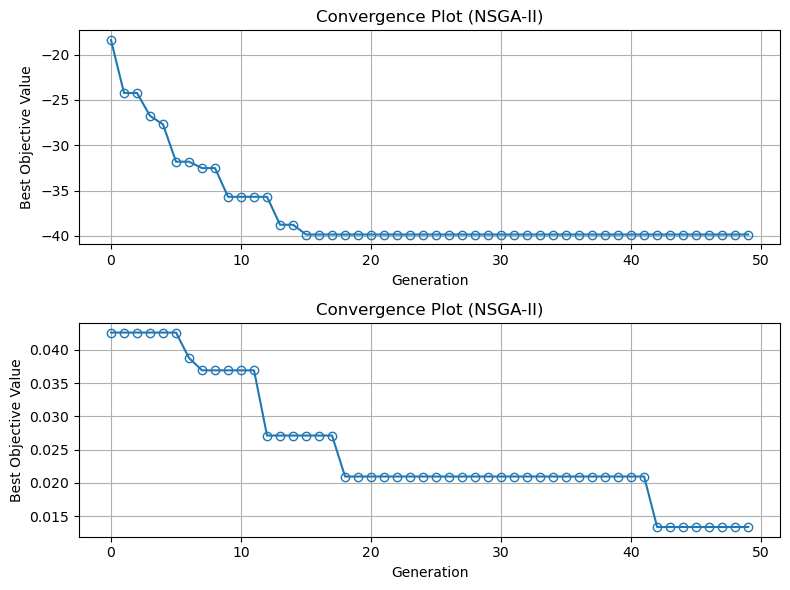

In [12]:
n_gen = len(lvdt_result.history)
f_min_values = [gen.opt.get("F").min(axis=0) for gen in lvdt_result.history]
f_min_values = np.array(f_min_values)  # 转换为 NumPy 数组

plt.figure (figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.plot(f_min_values[:, 0], marker = 'o',markerfacecolor='none', label="Min f1 (Sensitivity)")
plt.xlabel("Generation")
plt.ylabel("Best Objective Value")
plt.title("Convergence Plot (NSGA-II)")
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(f_min_values[:, 1], marker = 'o',markerfacecolor='none', label="Min f2 (Non-linear error)")
plt.xlabel("Generation")
plt.ylabel("Best Objective Value")
plt.title("Convergence Plot (NSGA-II)")
plt.grid()
plt.tight_layout()
plt.savefig("../solutions/convergence_plot_50gen.pdf")


#### History input and output visualization

In [14]:
solution = "../solutions/lvdt_50gen.pkl"
with open(solution, "rb") as f:
    lvdt_result = pickle.load(f)
    
input = []
output = []
for gen, algo in enumerate(lvdt_result.history):
    pop = algo.pop
    X = pop.get("X")
    F = pop.get("F")
    input.append(X)
    output.append(F)


In [27]:
nli_dict = dict()
di_dict = dict()
li_dict = dict()
nlo_dict = dict()
do_dict = dict()
lo_dict = dict()
dio_dict = dict()
for i, x in enumerate(input): # 50 generations
    nli_dict[str(i)] = nli = []
    di_dict[str(i)] = di = []
    li_dict[str(i)] = li = []
    nlo_dict[str(i)] = nlo = []
    do_dict[str(i)] = do = []
    lo_dict[str(i)] = lo = []
    dio_dict[str(i)] = dio = []

    for y in x: # 50 individuals
        nli.append(y[0])
        di.append(y[1])
        li.append(y[2])
        nlo.append(y[3])
        do.append(y[4])
        lo.append(y[5])
        dio.append(y[6])
sensi_dict = dict()
nle_dict = dict()
for j, m in enumerate(output): # 50 generations
    sensi_dict[str(j)] = sensi = []
    nle_dict[str(j)] = nle = []

    for n in m: # 50 individuals
        sensi.append(n[0])
        nle.append(n[1])

In [28]:
nli_value = np.array([x for x in nli_dict.values()])
di_value = np.array([x for x in di_dict.values()])
li_value = np.array([x for x in li_dict.values()])
nlo_value = np.array([x for x in nlo_dict.values()])
do_value = np.array([x for x in do_dict.values()])
lo_value = np.array([x for x in lo_dict.values()])
dio_value = np.array([x for x in dio_dict.values()])

sensi_value = np.array([x for x in sensi_dict.values()])
nle_value = np.array([x for x in nle_dict.values()])


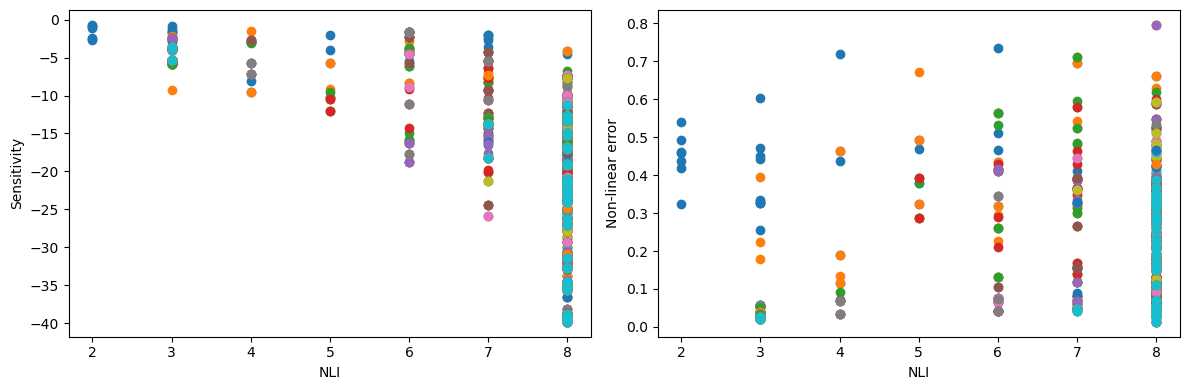

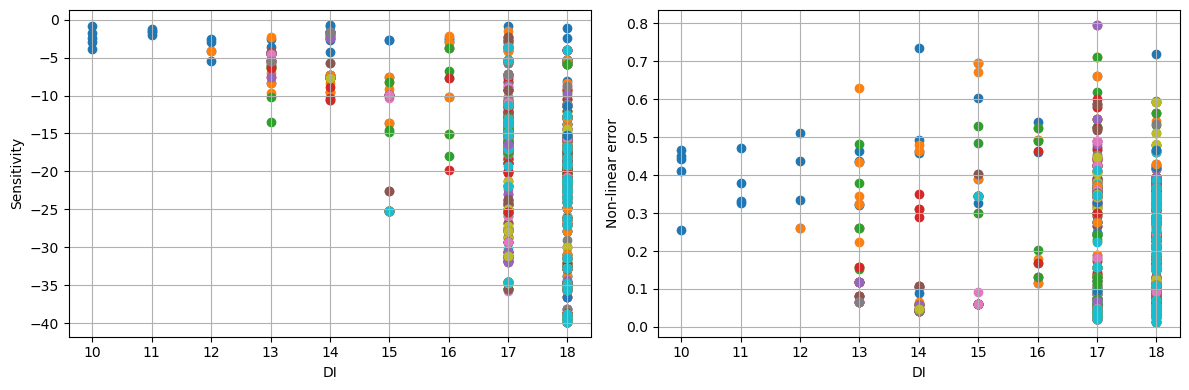

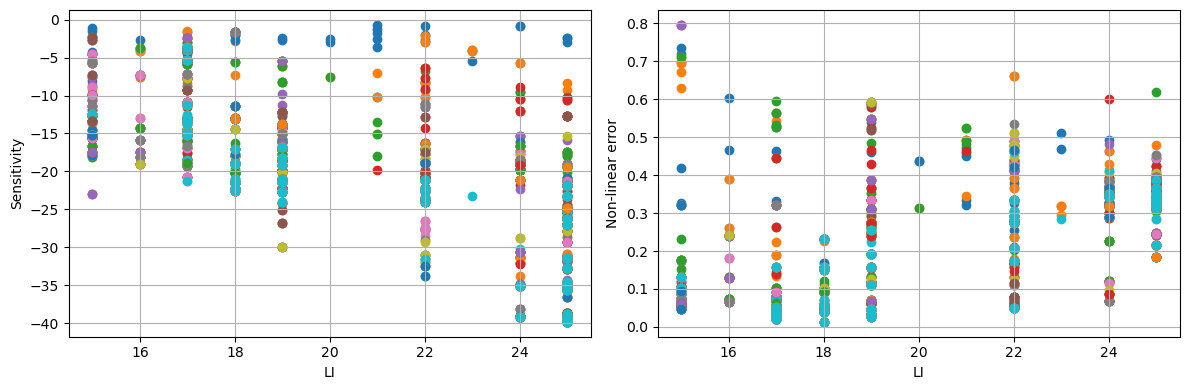

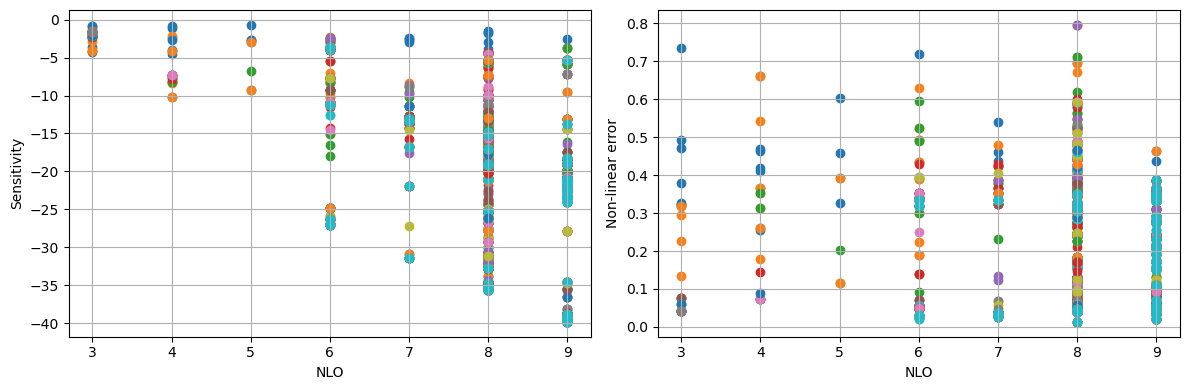

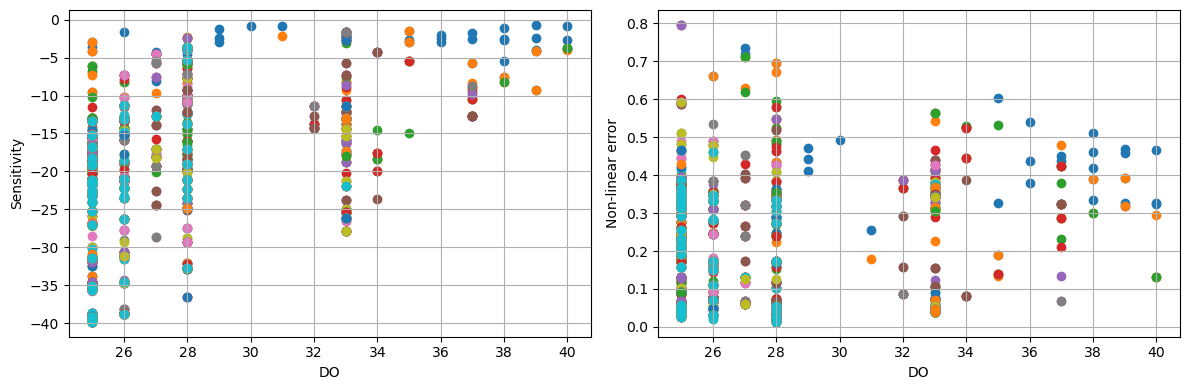

In [66]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
for nli, sensi in zip(nli_value, sensi_value):
    plt.scatter(nli, sensi)
    plt.xlabel("NLI")
    plt.ylabel("Sensitivity")
    plt.grid()

plt.subplot(1, 2, 2)
for nli, nle in zip(nli_value, nle_value):
    plt.scatter(nli, nle)
    plt.xlabel("NLI")
    plt.ylabel("Non-linear error")
    plt.grid()
    plt.tight_layout()

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
for di, sensi in zip(di_value, sensi_value):
    plt.scatter(di, sensi)
plt.xlabel("DI")
plt.ylabel("Sensitivity")
plt.grid()

plt.subplot(1, 2, 2)
for di, nle in zip(di_value, nle_value):
    plt.scatter(di, nle)
plt.xlabel("DI")
plt.ylabel("Non-linear error")
plt.grid()
plt.tight_layout()

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
for li, sensi in zip(li_value, sensi_value):
    plt.scatter(li, sensi)
plt.xlabel("LI")
plt.ylabel("Sensitivity")
plt.grid()

plt.subplot(1, 2, 2)
for li, nle in zip(li_value, nle_value):
    plt.scatter(li, nle)
plt.xlabel("LI")
plt.ylabel("Non-linear error")
plt.grid()
plt.tight_layout()

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
for nlo, sensi in zip(nlo_value, sensi_value):
    plt.scatter(nlo, sensi)
plt.xlabel("NLO")
plt.ylabel("Sensitivity")
plt.grid()

plt.subplot(1, 2, 2)
for nlo, nle in zip(nlo_value, nle_value):
    plt.scatter(nlo, nle)
plt.xlabel("NLO")
plt.ylabel("Non-linear error")
plt.grid()
plt.tight_layout()

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
for do, sensi in zip(do_value, sensi_value):
    plt.scatter(do, sensi)
plt.xlabel("DO")
plt.ylabel("Sensitivity")
plt.grid()

plt.subplot(1, 2, 2)
for do, nle in zip(do_value, nle_value):
    plt.scatter(do, nle)
plt.xlabel("DO")
plt.ylabel("Non-linear error")
plt.grid()
plt.tight_layout()



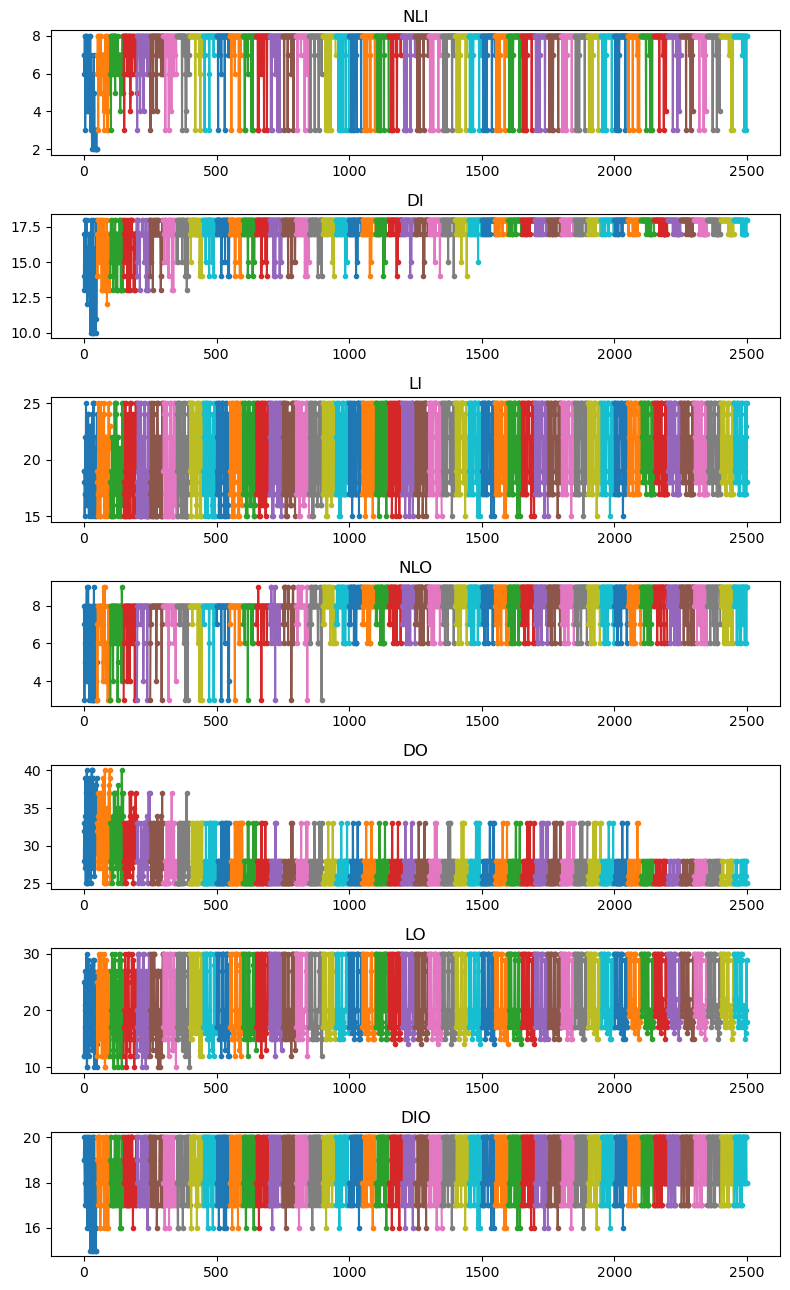

In [67]:
x_num = 50
plt.figure(figsize=(8, 13))
plt.subplot(7,1,1)
xaxis_nli = np.array(range(x_num))
for key, value in nli_dict.items():
    plt.plot(xaxis_nli, value, marker = '.')
    xaxis_nli += x_num
plt.title("NLI")

plt.subplot(7,1,2)
xaxis_di = np.array(range(x_num))
for key, value in di_dict.items():
    plt.plot(xaxis_di, value, marker = '.')
    xaxis_di += x_num
plt.title("DI")

plt.subplot(7,1,3)
xaxis_li = np.array(range(x_num))
for key, value in li_dict.items():
    plt.plot(xaxis_li, value, marker = '.')
    xaxis_li += x_num
plt.title("LI")

plt.subplot(7,1,4)
xaxis_nlo = np.array(range(x_num))
for key, value in nlo_dict.items():
    plt.plot(xaxis_nlo, value, marker = '.')
    xaxis_nlo += x_num
plt.title("NLO")

plt.subplot(7,1,5)
xaxis_do = np.array(range(x_num))
for key, value in do_dict.items():
    plt.plot(xaxis_do, value, marker = '.')
    xaxis_do += x_num
plt.title("DO")

plt.subplot(7,1,6)
xaxis_lo = np.array(range(x_num))
for key, value in lo_dict.items():
    plt.plot(xaxis_lo, value, marker = '.')
    xaxis_lo += x_num
plt.title("LO")

plt.subplot(7,1,7)
xaxis_dio = np.array(range(x_num))
for key, value in dio_dict.items():
    plt.plot(xaxis_dio, value, marker = '.')
    xaxis_dio += x_num
plt.title("DIO")
plt.tight_layout()
# plt.savefig("input.pdf", format='pdf')


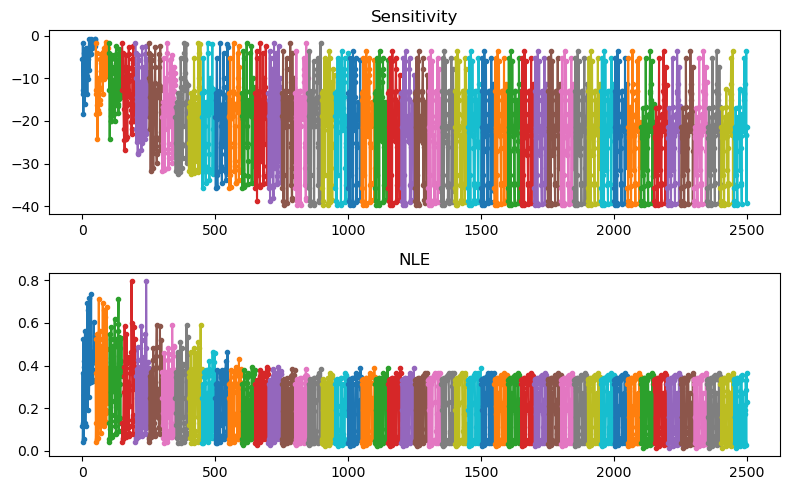

In [547]:
plt.figure(figsize=(8, 5))
plt.subplot(2,1,1)
xaxis_sensi = np.array(range(x_num))

for key, value in sensi_dict.items():
    plt.plot(xaxis_sensi, value, marker = '.')
    xaxis_sensi += x_num
plt.title("Sensitivity")

plt.subplot(2,1,2)
xaxis_nle = np.array(range(x_num))
for key, value in nle_dict.items():
    plt.plot(xaxis_nle, value, marker = '.')
    xaxis_nle += x_num
plt.title("NLE")
plt.tight_layout()

